<a href="https://colab.research.google.com/github/spacexcadet432/AutoRAG-Optimizer/blob/main/Credit_Card_Fraud_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kagglehub[pandas-datasets] imbalanced-learn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

from imblearn.over_sampling import SMOTE

import kagglehub
from kagglehub import KaggleDatasetAdapter

In [ ]:
file_path = "creditcard.csv"

data = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "mlg-ulb/creditcardfraud",
    file_path
)

print("Original Shape:", data.shape)
data.head()

/tmp/ipykernel_5871/3417473187.py:3: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  data = kagglehub.load_dataset(


Using Colab cache for faster access to the 'creditcardfraud' dataset.
Original Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
# Reduce size for faster training
data = data.sample(n=50000, random_state=42)

print("Reduced Shape:", data.shape)

Reduced Shape: (50000, 31)


In [ ]:
X = data.drop("Class", axis=1)
y = data["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
smote = SMOTE()

X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE:", np.bincount(y_train))

After SMOTE: [39925 39925]


In [ ]:
models = {
    "SVM": CalibratedClassifierCV(LinearSVC(), cv=3),
    "Random Forest": RandomForestClassifier(n_estimators=50, n_jobs=-1),
    "Decision Tree": DecisionTreeClassifier(max_depth=10)
}

results = {}

In [ ]:
for name, model in models.items():

    print(f"\nTraining {name}...")

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)

    print(f"\n{name} Results:")
    print(classification_report(y_test, y_pred))

    results[name] = (y_pred, y_prob)


Training SVM...

SVM Results:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      9992
           1       0.02      0.75      0.05         8

    accuracy                           0.97     10000
   macro avg       0.51      0.86      0.52     10000
weighted avg       1.00      0.97      0.99     10000


Training Random Forest...

Random Forest Results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9992
           1       1.00      0.62      0.77         8

    accuracy                           1.00     10000
   macro avg       1.00      0.81      0.88     10000
weighted avg       1.00      1.00      1.00     10000


Training Decision Tree...

Decision Tree Results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9992
           1       0.09      0.50      0.16         8

    accuracy                           1.00     1

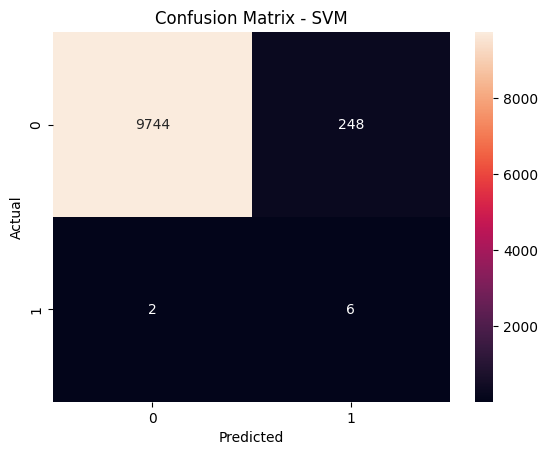

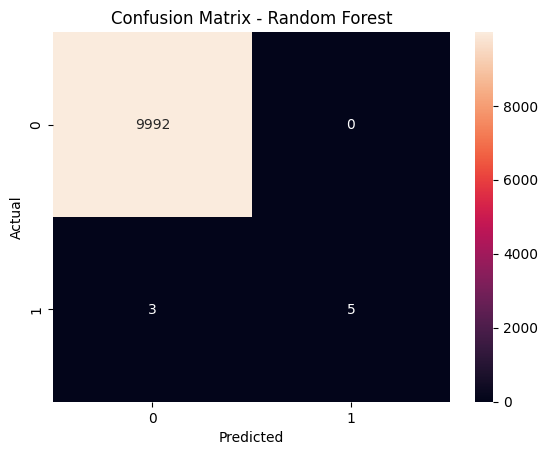

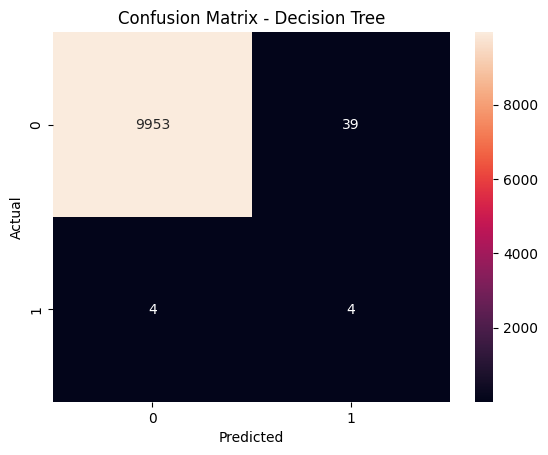

In [ ]:
for name, (y_pred, _) in results.items():
    cm = confusion_matrix(y_test, y_pred)

    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

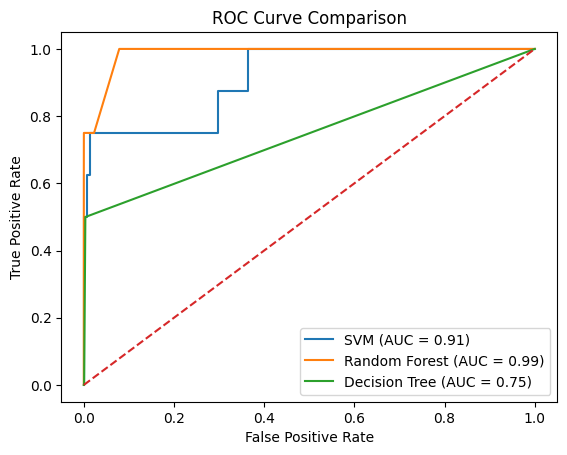

In [ ]:
plt.figure()

for name, (_, y_prob) in results.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

           Model  Precision  Recall  F1 Score
0            SVM   0.023622   0.750  0.045802
1  Random Forest   1.000000   0.625  0.769231
2  Decision Tree   0.093023   0.500  0.156863


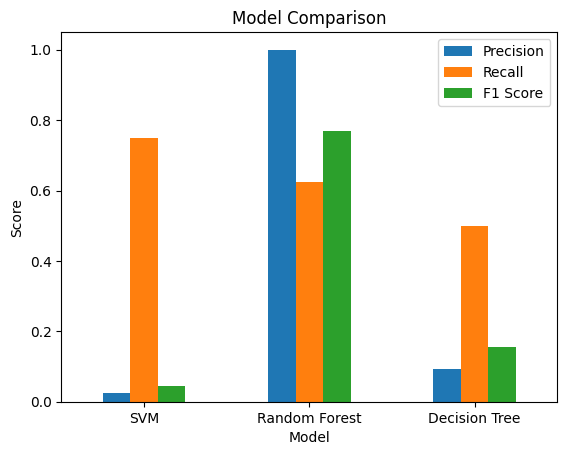

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

metrics = []

for name, (y_pred, _) in results.items():
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    metrics.append([name, precision, recall, f1])

metrics_df = pd.DataFrame(metrics, columns=["Model", "Precision", "Recall", "F1 Score"])

print(metrics_df)

metrics_df.set_index("Model").plot(kind='bar')
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()